# Visual Document Retrieval — Approche B : ColQwen2.5-3B

**Pipeline VDR** basé sur [ColQwen2.5-3B](https://huggingface.co/vidore/colqwen2.5-3b-pt-20250119-v0.2)  
- Modèle : ColQwen2.5-3B (late interaction multimodale, famille ColPali)
- Dataset : ViDoRe V3 Pharmaceuticals
- Évaluation : nDCG@5
- Comparaison requête par requête vs baseline textuel (BioBERT, nDCG@5 = 0.1029)
- Visualisation bounding boxes pour valider l'attention spatiale

In [ ]:
#  Dépendances 
# pip install colpali-engine datasets pillow numpy torch transformers tqdm matplotlib seaborn


import warnings
warnings.filterwarnings('ignore')
from tqdm.auto import tqdm
import os, json, io, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm
from PIL import Image
import torch

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

#  Détection device ─
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print(f'Device : {DEVICE} | dtype : {DTYPE}')
print('Approche B — ColQwen2.5-3B (late interaction multimodale)')

Device : cpu | dtype : torch.float32
Approche B — ColQwen2.5-3B (late interaction multimodale)


In [1]:
import torch, transformers, peft, accelerate
print(torch.__version__)
print(transformers.__version__)
print(peft.__version__)
print(accelerate.__version__)

from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor
print("imports OK")

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.10.0+cu128
5.3.0
0.18.1
1.13.0
imports OK


In [3]:
import torch
from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor

MODEL_NAME = "vidore/colqwen2.5-v0.2"

model = ColQwen2_5.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
).eval()

processor = ColQwen2_5_Processor.from_pretrained(MODEL_NAME)

print("Chargement OK :", MODEL_NAME)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/506 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Chargement OK : vidore/colqwen2.5-v0.2


In [ ]:
#  Chargement du corpus ViDoRe V3 Pharmaceuticals 
from datasets import load_dataset

print('Chargement du corpus ViDoRe V3 Pharmaceuticals...')
corpus_ds  = load_dataset('vidore/vidore_v3_pharmaceuticals', 'corpus',  split='test')
queries_ds = load_dataset('vidore/vidore_v3_pharmaceuticals', 'queries', split='test')
qrels_ds   = load_dataset('vidore/vidore_v3_pharmaceuticals', 'qrels',   split='test')

df_queries = queries_ds.to_pandas()
df_qrels   = qrels_ds.to_pandas()

# Garder uniquement les métadonnées (pas les images en RAM)
df_corpus = corpus_ds.to_pandas().drop(columns=['image'], errors='ignore')
df_corpus['corpus_idx'] = range(len(df_corpus))

print(f'Corpus  : {len(df_corpus):,} pages')
print(f'Queries : {len(df_queries):,} requêtes')
print(f'Qrels   : {len(df_qrels):,} paires de pertinence')
print(f'Colonnes corpus : {df_corpus.columns.tolist()}')

Chargement du corpus ViDoRe V3 Pharmaceuticals...


Generating test split: 100%|██████████| 10392/10392 [00:00<00:00, 947506.79 examples/s]


Corpus  : 2,313 pages
Queries : 2,184 requêtes
Qrels   : 10,392 paires de pertinence
Colonnes corpus : ['corpus_id', 'doc_id', 'markdown', 'page_number_in_doc', 'corpus_idx']


In [ ]:
#  Utilitaires image
def to_pil(img_field) -> Image.Image:
    """Convertit un champ image HuggingFace (dict, bytes, PIL) en PIL.Image RGB."""
    if img_field is None:
        return Image.new('RGB', (400, 300), color='white')
    if isinstance(img_field, Image.Image):
        return img_field.convert('RGB')
    if isinstance(img_field, dict):
        raw = img_field.get('bytes') or img_field.get('data')
        if raw:
            return Image.open(io.BytesIO(raw)).convert('RGB')
        path = img_field.get('path')
        if path:
            return Image.open(path).convert('RGB')
    if isinstance(img_field, bytes):
        return Image.open(io.BytesIO(img_field)).convert('RGB')
    try:
        return Image.fromarray(np.uint8(img_field)).convert('RGB')
    except Exception:
        return Image.new('RGB', (400, 300), color='white')

print('Utilitaires image définis.')

Utilitaires image définis.


In [ ]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'  # réduit la fragmentation

BATCH_SIZE_IMG = 2   #  batch minimal
CACHE_PATH = 'colqwen_corpus_embeddings.pt'

corpus_ids_b   = df_corpus['corpus_id'].tolist()
corpus_indices = df_corpus['corpus_idx'].tolist()

if os.path.exists(CACHE_PATH):
    print(f'Cache trouvé : {CACHE_PATH} — chargement...')
    cache_data = torch.load(CACHE_PATH, map_location='cpu')
    corpus_embeddings_list = cache_data['embeddings']
    corpus_ids_b = cache_data['corpus_ids']
    print(f'Chargé : {len(corpus_embeddings_list)} pages')
else:
    corpus_embeddings_list = []

    with torch.no_grad():
        for i in tqdm(range(0, len(corpus_indices), BATCH_SIZE_IMG),
                      desc='Encoding pages (ColQwen2.5)'):
            batch_indices = corpus_indices[i:i+BATCH_SIZE_IMG]
            batch_pil = [to_pil(corpus_ds[int(idx)]['image']) for idx in batch_indices]

            batch_inputs = processor.process_images(batch_pil).to(DEVICE)
            embs = model(**batch_inputs)

            for emb in embs:
                corpus_embeddings_list.append(emb.detach().cpu())

            # Nettoyage agressif entre chaque batch
            del batch_pil, batch_inputs, embs
            gc.collect()
            torch.cuda.empty_cache()

    torch.save({'embeddings': corpus_embeddings_list, 'corpus_ids': corpus_ids_b}, CACHE_PATH)
    print(f'Cache sauvegardé : {len(corpus_embeddings_list)} pages')

print(f'Corpus encodé : {len(corpus_embeddings_list)} pages')
print(f'Exemple : page 0 → shape {corpus_embeddings_list[0].shape}')

Encoding pages (ColQwen2.5):   0%|          | 0/1157 [00:00<?, ?it/s]

Cache sauvegardé : 2313 pages
Corpus encodé : 2313 pages
Exemple : page 0 → shape torch.Size([731, 128])


In [12]:
import json

corpus_embeddings_json = {
    cid: emb.float().numpy().tolist()  # bfloat16 → float32 → numpy
    for cid, emb in zip(corpus_ids_b, corpus_embeddings_list)
}

with open('colqwen_corpus_embeddings.json', 'w') as f:
    json.dump(corpus_embeddings_json, f)

print(f'Sauvegardé : colqwen_corpus_embeddings.json')
print(f'Nombre de pages : {len(corpus_embeddings_json)}')

Sauvegardé : colqwen_corpus_embeddings.json
Nombre de pages : 2313


In [ ]:
# Encodage des requêtes — ColQwen2.5
# Les requêtes textuelles sont aussi encodées en multi-vecteurs (tokens).
# Score final : MaxSim entre chaque token de requête et chaque patch de page.

CACHE_QUERIES = 'colqwen_query_embeddings.pt'

query_ids_b   = df_queries['query_id'].tolist()
query_texts_b = df_queries['query'].tolist()

if os.path.exists(CACHE_QUERIES):
    print(f'Cache requêtes trouvé — chargement...')
    cache_q = torch.load(CACHE_QUERIES, map_location='cpu')
    query_embeddings_list = cache_q['embeddings']
    query_ids_b = cache_q['query_ids']
    print(f'Chargé : {len(query_embeddings_list)} requêtes')
else:
    BATCH_Q = 8
    query_embeddings_list = []

    with torch.no_grad():
        for i in tqdm(range(0, len(query_texts_b), BATCH_Q),
                      desc='Encoding queries (ColQwen2.5)'):
            batch_texts = query_texts_b[i:i+BATCH_Q]
            batch_inputs = processor.process_queries(batch_texts).to(DEVICE)
            embs = model(**batch_inputs)  # (batch, n_tokens, dim)
            for emb in embs:
                query_embeddings_list.append(emb.cpu())
            del batch_inputs, embs
            gc.collect()

    torch.save({'embeddings': query_embeddings_list, 'query_ids': query_ids_b}, CACHE_QUERIES)
    print(f'Cache sauvegardé : {len(query_embeddings_list)} requêtes')

print(f'Requêtes encodées : {len(query_embeddings_list)}')
print(f'Exemple : requête 0 → shape {query_embeddings_list[0].shape}')

Encoding queries (ColQwen2.5):   0%|          | 0/273 [00:00<?, ?it/s]

Cache sauvegardé : 2184 requêtes
Requêtes encodées : 2184
Exemple : requête 0 → shape torch.Size([39, 128])


In [14]:
import json

query_embeddings_json = {
    cid: emb.float().numpy().tolist()  # bfloat16 → float32 → numpy
    for cid, emb in zip(query_ids_b, query_embeddings_list)
}

with open('colqwen_query_embeddings.json', 'w') as f:
    json.dump(query_embeddings_json, f)

print(f'Sauvegardé : colqwen_query_embeddings.json')
print(f'Nombre de requetes : {len(query_embeddings_json)}')

Sauvegardé : colqwen_query_embeddings.json
Nombre de requetes : 2184


In [ ]:
import torch
import json

# Recharger seulement si nécessaire

cache_corpus = torch.load('colqwen_corpus_embeddings.pt', map_location='cpu')
corpus_embeddings_list = cache_corpus['embeddings']
corpus_ids_b = cache_corpus['corpus_ids']

cache_queries = torch.load('colqwen_query_embeddings.pt', map_location='cpu')
query_embeddings_list = cache_queries['embeddings']
query_ids_b = cache_queries['query_ids']

print(f'Corpus  rechargé : {len(corpus_embeddings_list)} pages')
print(f'Requêtes rechargées : {len(query_embeddings_list)} requêtes')
print(f'Exemple corpus  shape : {corpus_embeddings_list[0].shape}')
print(f'Exemple requête shape : {query_embeddings_list[0].shape}')

Corpus  rechargé : 2313 pages
Requêtes rechargées : 2184 requêtes
Exemple corpus  shape : torch.Size([731, 128])
Exemple requête shape : torch.Size([39, 128])


In [ ]:
# ─Score MaxSim (Late Interaction) +
# Score ColPali-style : sum_{token t} max_{patch p} sim(t, p)


from tqdm import tqdm  
def maxsim_score(query_emb: torch.Tensor, page_emb: torch.Tensor) -> float:
    """
    Calcule le score MaxSim entre une requête et une page.
    query_emb : (n_tokens, dim)
    page_emb  : (n_patches, dim)
    Retourne  : scalar float
    """
    # Normalisation L2
    q = query_emb.float()  # (n_tokens, dim)
    p = page_emb.float()   # (n_patches, dim)
    q = q / (q.norm(dim=-1, keepdim=True) + 1e-8)
    p = p / (p.norm(dim=-1, keepdim=True) + 1e-8)
    # Matrice de similarité : (n_tokens, n_patches)
    sim = torch.matmul(q, p.T)
    # MaxSim : max sur les patches pour chaque token, puis somme
    return sim.max(dim=1).values.sum().item()


def compute_retrieval_colqwen(query_embeddings, corpus_embeddings,
                               query_ids, corpus_ids, k=10):
    """
    Calcule les résultats de retrieval via MaxSim (ColQwen2.5).
    Retourne un dict {query_id: [(corpus_id, score), ...]}
    """
    results = {}
    for i, (qid, q_emb) in enumerate(tqdm(
            zip(query_ids, query_embeddings),
            total=len(query_ids), desc='MaxSim retrieval')):
        scores = [
            (cid, maxsim_score(q_emb, p_emb))
            for cid, p_emb in zip(corpus_ids, corpus_embeddings)
        ]
        scores.sort(key=lambda x: -x[1])
        results[qid] = scores[:k]
    return results


print('Calcul MaxSim (ColQwen2.5 Late Interaction)...')
print('Note : le calcul est O(n_queries × n_corpus) — peut être long sur CPU.')
results_b = compute_retrieval_colqwen(
    query_embeddings_list, corpus_embeddings_list,
    query_ids_b, corpus_ids_b, k=10
)
print(f'Résultats calculés pour {len(results_b):,} requêtes.')

Calcul MaxSim (ColQwen2.5 Late Interaction)...
Note : le calcul est O(n_queries × n_corpus) — peut être long sur CPU.


MaxSim retrieval: 100%|██████████| 2184/2184 [43:26<00:00,  1.19s/it]

Résultats calculés pour 2,184 requêtes.


In [ ]:
#  Évaluation nDCG@5 

def compute_ndcg_at_k(results, df_qrels, k=5):
    """Calcule le nDCG@k pour chaque requête."""
    gt = defaultdict(dict)
    for _, row in df_qrels.iterrows():
        gt[row['query_id']][row['corpus_id']] = row['score']

    ndcg_scores = {}
    for qid, ranked_list in results.items():
        if qid not in gt:
            continue
        relevant = gt[qid]
        dcg = sum(
            (2**relevant.get(cid, 0) - 1) / np.log2(rank + 1)
            for rank, (cid, _) in enumerate(ranked_list[:k], start=1)
        )
        ideal_rels = sorted(relevant.values(), reverse=True)[:k]
        idcg = sum(
            (2**rel - 1) / np.log2(rank + 1)
            for rank, rel in enumerate(ideal_rels, start=1)
        )
        ndcg_scores[qid] = dcg / idcg if idcg > 0 else 0.0
    return ndcg_scores


# Filtrer les qrels sur les corpus_id disponibles
corpus_ids_set = set(corpus_ids_b)
df_qrels_filtered = df_qrels[df_qrels['corpus_id'].isin(corpus_ids_set)]

ndcg_b = compute_ndcg_at_k(results_b, df_qrels_filtered, k=5)
mean_ndcg_b = np.mean(list(ndcg_b.values()))

# Score baseline textuel (BioBERT, Approche A)
NDCG_A = 0.1029
delta = mean_ndcg_b - NDCG_A

print(f'\n{"="*60}')
print(f'  Approche B — ColQwen2.5-3B — nDCG@5 : {mean_ndcg_b:.4f}')
print(f'  Médiane                              : {np.median(list(ndcg_b.values())):.4f}')
print(f'  % requêtes à 0.0                     : {sum(1 for v in ndcg_b.values() if v == 0) / len(ndcg_b) * 100:.1f}%')
print(f'  % requêtes à 1.0                     : {sum(1 for v in ndcg_b.values() if v == 1) / len(ndcg_b) * 100:.1f}%')
print(f'  N requêtes évaluées                  : {len(ndcg_b):,}')
print('='*60)
print(f'\n  Baseline textuel (Approche A / BioBERT) : nDCG@5 = {NDCG_A:.4f}')
print(f'  Delta vs Approche A : {delta:+.4f} ({"✓ GAIN" if delta > 0 else "✗ PERTE"})')
print('='*60)


  Approche B — ColQwen2.5-3B — nDCG@5 : 0.5718
  Médiane                              : 0.6164
  % requêtes à 0.0                     : 14.6%
  % requêtes à 1.0                     : 26.6%
  N requêtes évaluées                  : 2,184

  Baseline textuel (Approche A / BioBERT) : nDCG@5 = 0.1029
  Delta vs Approche A : +0.4689 (✓ GAIN)


In [ ]:
#  Utilitaires Bounding Boxes 

def extract_bboxes(raw) -> list:
    """
    Convertit le champ bounding_boxes ViDoRe V3 en liste de dicts normalisés.
    Format attendu : {'x1', 'y1', 'x2', 'y2'} en pixels absolus.
    """
    if raw is None:
        return []
    if isinstance(raw, np.ndarray):
        raw = raw.tolist()
    if not isinstance(raw, list):
        return []
    result = []
    for item in raw:
        if isinstance(item, np.ndarray):
            item = item.tolist()
        if isinstance(item, dict):
            if 'x1' in item:
                result.append({'x1': item['x1'], 'y1': item['y1'],
                               'x2': item['x2'], 'y2': item['y2']})
            elif 'x' in item:
                result.append(item)
    return result


def compute_patch_attention(query_emb: torch.Tensor,
                            page_emb: torch.Tensor,
                            n_patches_h: int = 16,
                            n_patches_w: int = 16) -> np.ndarray:
    """
    Calcule la carte d'attention par patch (MaxSim par patch).
    query_emb : (n_tokens, dim)
    page_emb  : (n_patches, dim)  — attention : n_patches peut ≠ n_patches_h*n_patches_w
    Retourne  : (n_patches_h, n_patches_w) — reshaped si possible, sinon 1D
    """
    q = query_emb.float()
    p = page_emb.float()
    q = q / (q.norm(dim=-1, keepdim=True) + 1e-8)
    p = p / (p.norm(dim=-1, keepdim=True) + 1e-8)
    # sim : (n_tokens, n_patches)
    sim = torch.matmul(q, p.T)
    # Score par patch = max sur les tokens
    patch_scores = sim.max(dim=0).values.numpy()  # (n_patches,)

    # Essayer de reshaper en grille
    n_p = len(patch_scores)
    side = int(np.sqrt(n_p))
    if side * side == n_p:
        return patch_scores.reshape(side, side)
    else:
        # Reshape best-effort
        target = n_patches_h * n_patches_w
        if n_p >= target:
            return patch_scores[:target].reshape(n_patches_h, n_patches_w)
        else:
            # Padding
            padded = np.zeros(target)
            padded[:n_p] = patch_scores
            return padded.reshape(n_patches_h, n_patches_w)


print('Fonctions bounding boxes et attention patch définies.')

Fonctions bounding boxes et attention patch définies.


Requêtes avec nDCG@5 ≥ 0.8 : 765 — affichage des 3 meilleures


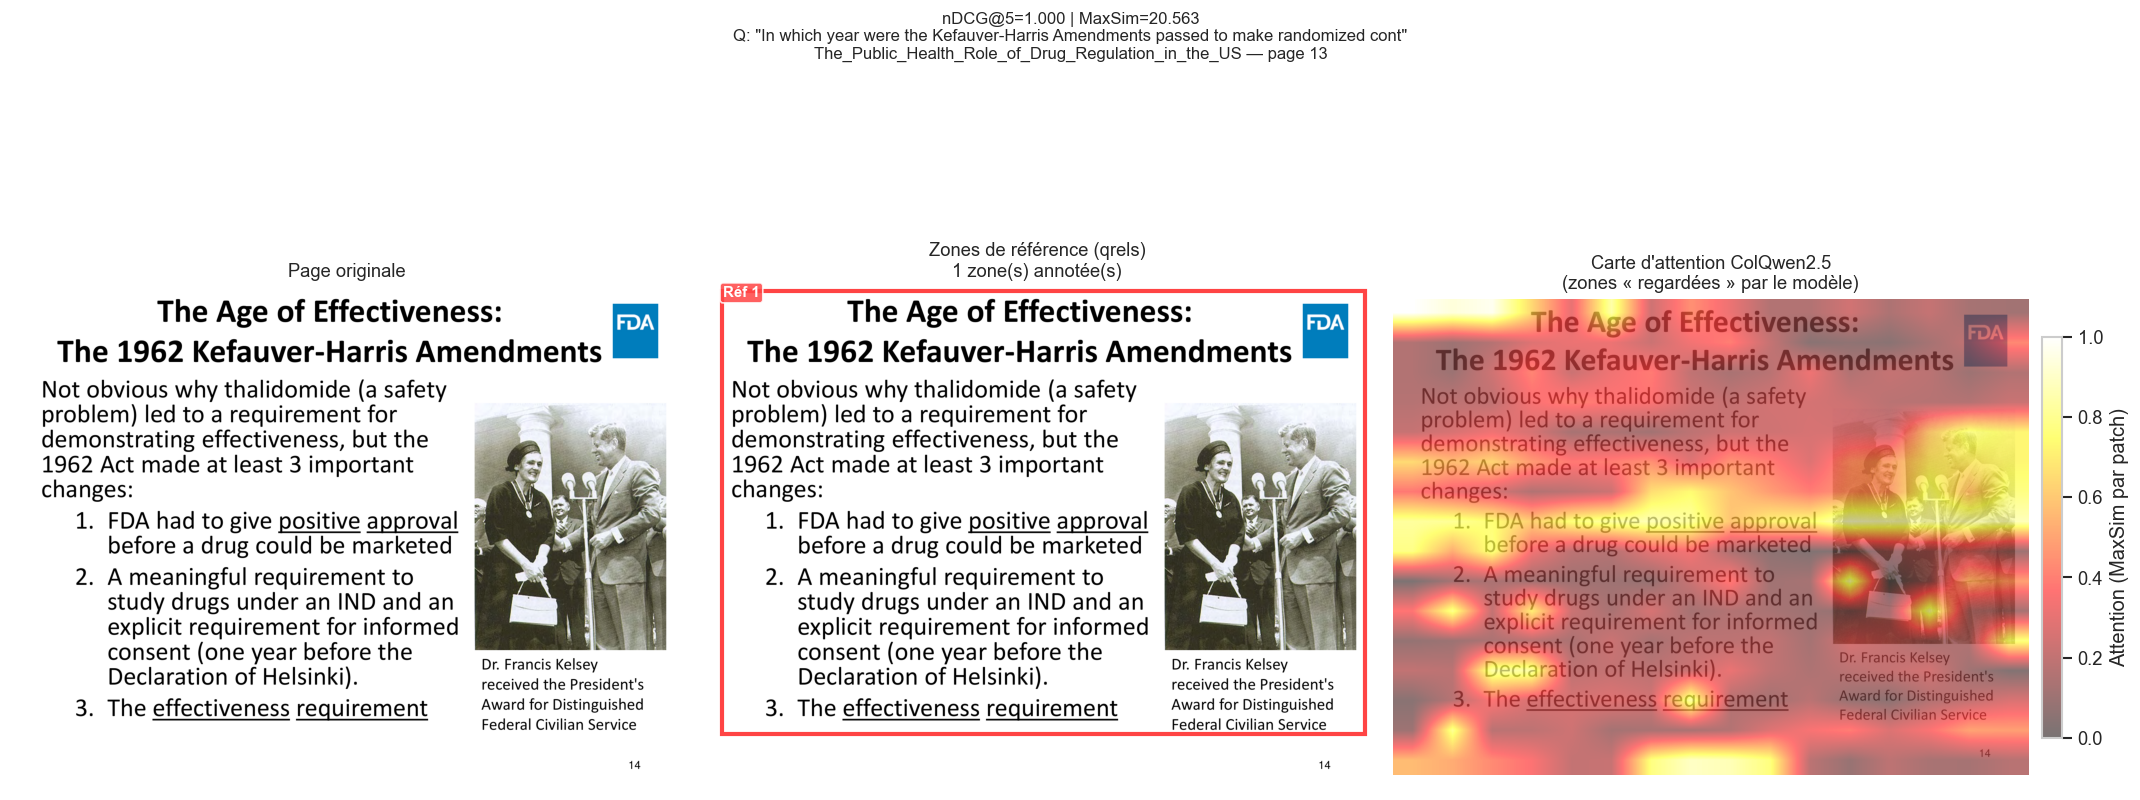


  nDCG@5=1.000 | MaxSim=20.563
  Requête  : In which year were the Kefauver-Harris Amendments passed to make randomized controlled trials the standard for evaluating clinical efficacy?
  Page     : The_Public_Health_Role_of_Drug_Regulation_in_the_US p.13
  Bboxes   : 1 zone(s)


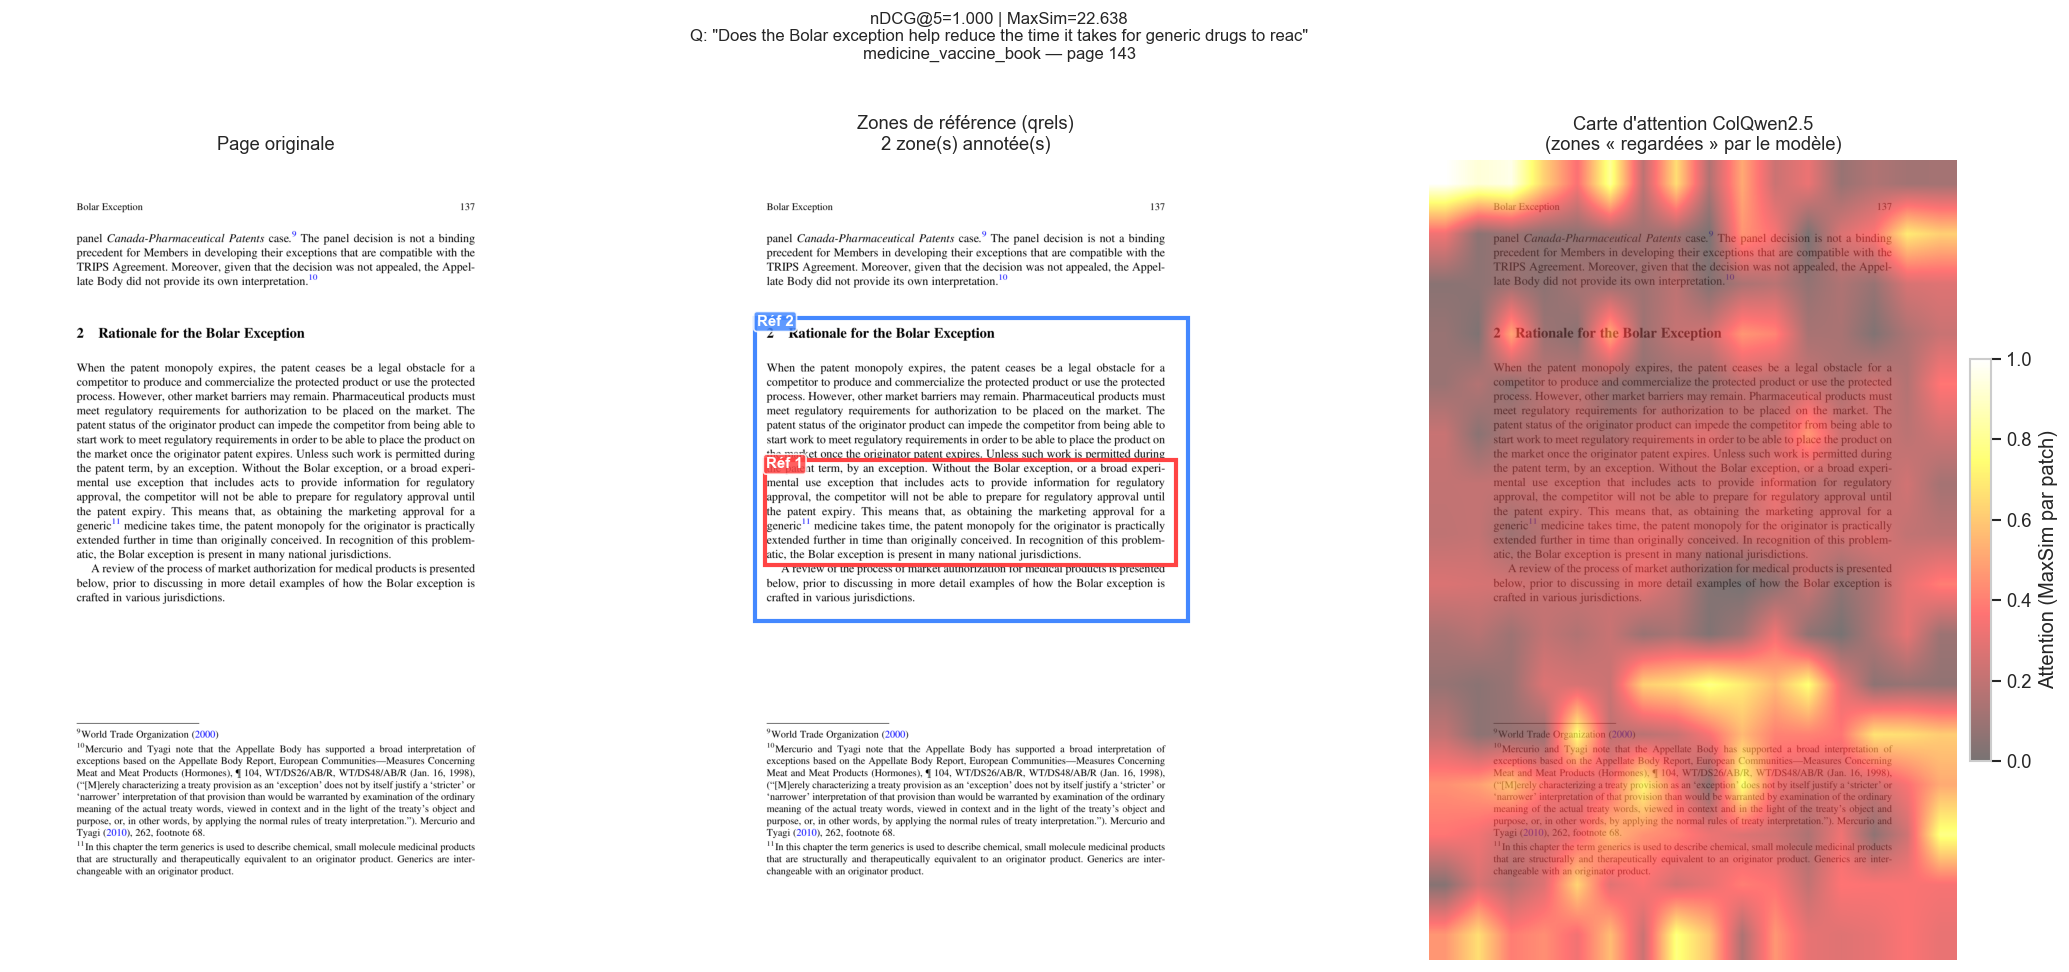


  nDCG@5=1.000 | MaxSim=22.638
  Requête  : Does the Bolar exception help reduce the time it takes for generic drugs to reach the market after a patent expires?
  Page     : medicine_vaccine_book p.143
  Bboxes   : 2 zone(s)


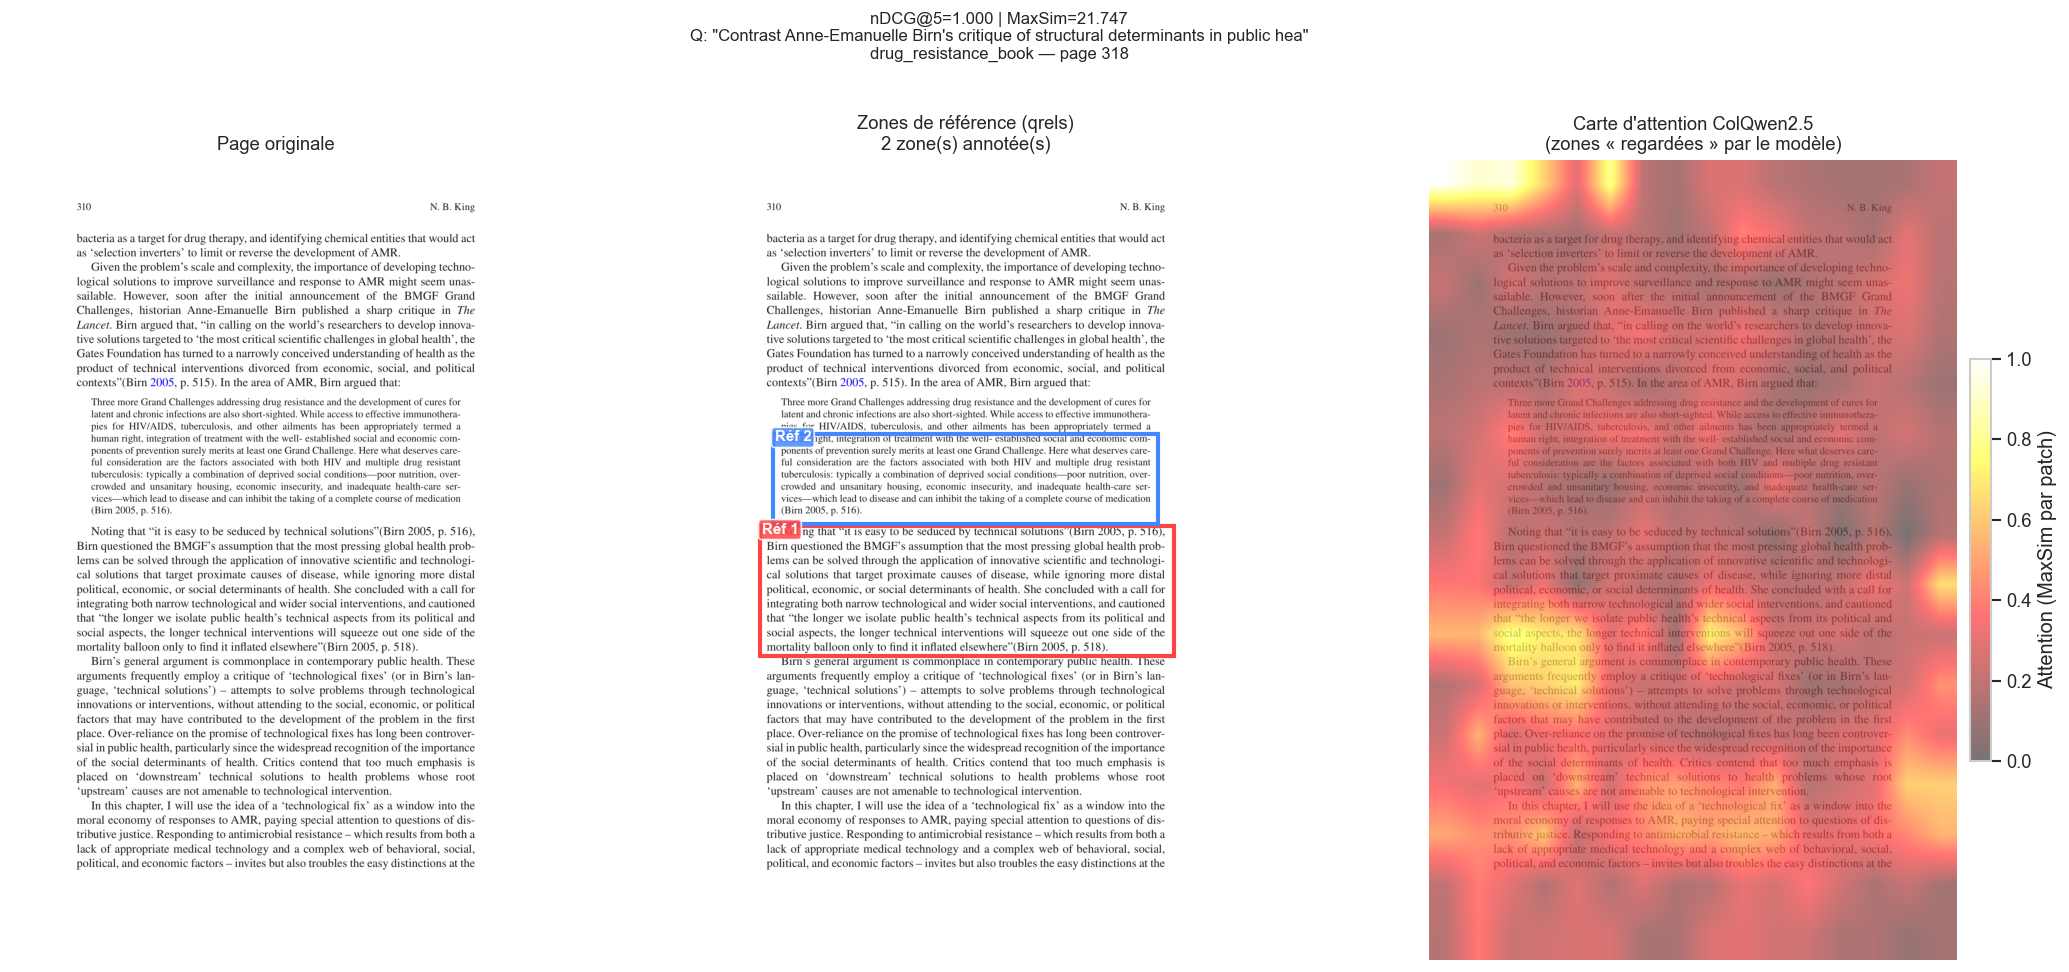


  nDCG@5=1.000 | MaxSim=21.747
  Requête  : Contrast Anne-Emanuelle Birn's critique of structural determinants in public health with a hypothetical proponent of purely biomedical interventions.
  Page     : drug_resistance_book p.318
  Bboxes   : 2 zone(s)


In [ ]:
#  Visualisation : Bounding Boxes + Carte d'attention ColQwen2.5 
# Pour chaque cas sélectionné :
#   - Colonne gauche : page brute
#   - Colonne centre : bboxes annotées (qrels) = zones de référence
#   - Colonne droite : carte d'attention ColQwen2.5 (ce que le modèle regarde)

corpusid_to_idx = dict(zip(df_corpus['corpus_id'], df_corpus['corpus_idx']))
corpusid_to_emb = dict(zip(corpus_ids_b, corpus_embeddings_list))
queryid_to_emb  = dict(zip(query_ids_b, query_embeddings_list))

corpus_docid_dict  = dict(zip(df_corpus['corpus_id'], df_corpus['doc_id']))
corpus_page_dict   = dict(zip(df_corpus['corpus_id'], df_corpus['page_number_in_doc']))
query_text_dict    = dict(zip(df_queries['query_id'], df_queries['query']))

# Construire le dict qrels avec bboxes
qrels_bbox_dict = defaultdict(list)
for _, row in df_qrels.iterrows():
    qrels_bbox_dict[(row['query_id'], row['corpus_id'])].append(
        extract_bboxes(row.get('bounding_boxes'))
    )

# Sélectionner les meilleurs cas (nDCG@5 ≥ 0.8)
good_cases = [(qid, score) for qid, score in ndcg_b.items() if score >= 0.8]
if not good_cases:
    good_cases = sorted(ndcg_b.items(), key=lambda x: -x[1])[:3]
    print(f'Fallback — 3 meilleurs scores : {[f"{s:.3f}" for _, s in good_cases]}')

print(f'Requêtes avec nDCG@5 ≥ 0.8 : {len(good_cases)} — affichage des 3 meilleures')


def draw_case(qid, ndcg_score):
    query_text = query_text_dict.get(qid, 'N/A')
    top_cid, top_score = results_b[qid][0]

    all_bboxes = []
    for bbox_list in qrels_bbox_dict.get((qid, top_cid), []):
        all_bboxes.extend(bbox_list)

    idx = corpusid_to_idx.get(top_cid)
    if idx is None:
        print(f'  Image non disponible pour {top_cid}')
        return

    page_img  = to_pil(corpus_ds[int(idx)]['image'])
    q_emb     = queryid_to_emb.get(qid)
    p_emb     = corpusid_to_emb.get(top_cid)
    doc_name  = corpus_docid_dict.get(top_cid, '?')
    page_num  = corpus_page_dict.get(top_cid, '?')
    w_img, h_img = page_img.size

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))

    # ── Gauche : page brute 
    axes[0].imshow(page_img)
    axes[0].set_title('Page originale', fontsize=11)
    axes[0].axis('off')

    # ── Centre : bboxes annotées (qrels)
    axes[1].imshow(page_img)
    colors = ['#FF4444', '#4488FF', '#44CC44', '#FF8800']
    for i, bbox in enumerate(all_bboxes):
        color = colors[i % len(colors)]
        if 'x1' in bbox:
            x, y = bbox['x1'], bbox['y1']
            bw, bh = bbox['x2'] - bbox['x1'], bbox['y2'] - bbox['y1']
        else:
            x      = bbox.get('x', 0) * w_img
            y      = bbox.get('y', 0) * h_img
            bw     = bbox.get('width',  0) * w_img
            bh     = bbox.get('height', 0) * h_img
        rect = patches.Rectangle((x, y), bw, bh,
                                   linewidth=2.5, edgecolor=color, facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(x+4, y+18, f'Réf {i+1}', color='white', fontsize=9,
                     fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85))
    n_bbox_label = f'{len(all_bboxes)} zone(s) annotée(s)' if all_bboxes else 'Pas de bbox'
    axes[1].set_title(f'Zones de référence (qrels)\n{n_bbox_label}', fontsize=11)
    axes[1].axis('off')

    # Droite : carte d'attention ColQwen2.5 
    axes[2].imshow(page_img, alpha=0.6)
    if q_emb is not None and p_emb is not None:
        attn_map = compute_patch_attention(q_emb, p_emb)
        # Normalisation [0, 1]
        attn_norm = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
        attn_img  = axes[2].imshow(
            attn_norm,
            cmap='hot', alpha=0.55,
            extent=[0, w_img, h_img, 0],
            interpolation='bilinear'
        )
        plt.colorbar(attn_img, ax=axes[2], fraction=0.03, pad=0.02,
                     label='Attention (MaxSim par patch)')
        axes[2].set_title('Carte d\'attention ColQwen2.5\n(zones « regardées » par le modèle)', fontsize=11)
    else:
        axes[2].text(0.5, 0.5, 'Embeddings non disponibles',
                     ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('Carte d\'attention (N/D)', fontsize=11)
    axes[2].axis('off')

    suptitle = (f'nDCG@5={ndcg_score:.3f} | MaxSim={top_score:.3f}\n'
                f'Q: "{query_text[:80]}"\n'
                f'{doc_name} — page {page_num}')
    fig.suptitle(suptitle, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig(f'bbox_case_{qid}.png', dpi=130, bbox_inches='tight')
    plt.show()

    print(f'\n  nDCG@5={ndcg_score:.3f} | MaxSim={top_score:.3f}')
    print(f'  Requête  : {query_text}')
    print(f'  Page     : {doc_name} p.{page_num}')
    print(f'  Bboxes   : {len(all_bboxes)} zone(s)')

    del page_img
    gc.collect()


for qid, score in sorted(good_cases, key=lambda x: -x[1])[:3]:
    draw_case(qid, score)

In [ ]:
#  Analyse des pires requêtes — ColQwen2.5 

gt_dict = defaultdict(dict)
for _, row in df_qrels.iterrows():
    gt_dict[row['query_id']][row['corpus_id']] = row['score']

corpus_meta_dict = dict(zip(
    df_corpus['corpus_id'],
    zip(df_corpus['doc_id'], df_corpus['page_number_in_doc'],
        df_corpus['markdown'].fillna('').str.len())
))

worst_queries_b = sorted(ndcg_b.items(), key=lambda x: x[1])[:10]

print('TOP 10 PIRES REQUÊTES — ColQwen2.5-3B')
print('='*80)

worst_analysis = []
for qid, score in worst_queries_b:
    query_text    = query_text_dict.get(qid, 'N/A')
    relevant_pages = gt_dict.get(qid, {})
    retrieved_top1 = results_b[qid][0][0] if results_b.get(qid) else None

    rel_info = []
    for cid, rel_score in relevant_pages.items():
        meta = corpus_meta_dict.get(cid, ('?', '?', 0))
        rel_info.append(f'{meta[0]} p.{meta[1]} (rel={rel_score}, ocr={meta[2]}c)')

    print(f'\nnDCG@5={score:.3f} | QID: {qid}')
    print(f'  Requête   : {query_text}')
    print(f'  Attendu   : {" | ".join(rel_info[:2])}' + (' ...' if len(rel_info)>2 else ''))
    if retrieved_top1:
        meta_r = corpus_meta_dict.get(retrieved_top1, ('?', '?', 0))
        print(f'  Récupéré  : {meta_r[0]} p.{meta_r[1]} (ocr={meta_r[2]}c)')

    worst_analysis.append({
        'query_id': qid, 'ndcg_colqwen': score,
        'ndcg_biobert': ndcg_a.get(qid, np.nan),
        'query': query_text[:60],
        'expected_doc': rel_info[0] if rel_info else 'N/A'
    })

df_worst = pd.DataFrame(worst_analysis)
print('\n\nTableau des 10 pires requêtes :')
from IPython.display import display
display(df_worst[['query', 'ndcg_colqwen', 'ndcg_biobert', 'expected_doc']])

TOP 10 PIRES REQUÊTES — ColQwen2.5-3B

nDCG@5=0.000 | QID: 6
  Requête   : Identify the FDA programs focused on enhancing access to generic medications and explain how these initiatives connect with actions taken to address the opioid epidemic.
  Attendu   : AAMGRxBiosimsSept2018_UHL p.26 (rel=1, ocr=766c) | AAMGRxBiosimsSept2018_UHL p.37 (rel=1, ocr=482c) ...
  Récupéré  : Presentation_FDA_Perspective_on_Abuse_Deterrent_Opioid_Development p.19 (ocr=421c)

nDCG@5=0.000 | QID: 8
  Requête   : Examine how the FDA's 2017 regulatory decisions and approaches to patient counseling aligned with the changing trends in opioid overdose fatalities.
  Attendu   : CDER_Office_of_Surveillance_and_Epidemiology_2017_Update p.30 (rel=1, ocr=276c) | CDER_Office_of_Surveillance_and_Epidemiology_2017_Update p.33 (rel=1, ocr=499c)
  Récupéré  : FDLI_FDA_CDER_PCavazzoni p.16 (ocr=739c)

nDCG@5=0.000 | QID: 13
  Requête   : How do past performance data influence the development of future regulatory approache

,query,ndcg_colqwen,ndcg_biobert,expected_doc
0,Identify the FDA programs focused on enhancing...,0.0,0.339782,"AAMGRxBiosimsSept2018_UHL p.26 (rel=1, ocr=766c)"
1,Examine how the FDA's 2017 regulatory decision...,0.0,0.032479,CDER_Office_of_Surveillance_and_Epidemiology_2...
2,How do past performance data influence the dev...,0.0,0.000000,FDA_Office_of_Generic_Drugs_OGD_Keynote_Addres...
3,patterns in SEND usage growth for investigatio...,0.0,0.018557,"CDER_SEND_Webinar_June_2020 p.35 (rel=1, ocr=5..."
4,What steps does the FDA take to ensure biosimi...,0.0,0.119538,Biosimilar_and_Interchangeable_Products_The_US...
5,What are the FDA's key initiatives introduced ...,0.0,0.159255,CDER_Office_of_Surveillance_and_Epidemiology_2...
6,Explain the regulatory differences between bio...,0.0,0.012804,Biosimilar_and_Interchangeable_Products_The_US...
7,Analyze how the implementation of the 21st Cen...,0.0,0.380742,"CDER_Update_Presentation p.1 (rel=1, ocr=267c)"
8,How do patent linkage and data exclusivity dif...,0.0,0.097526,"medicine_vaccine_book p.190 (rel=1, ocr=2449c)"
9,FDA regulatory framework for biosimilar and in...,0.0,0.000000,Biosimilar_and_Interchangeable_Products_The_US...
